In [35]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [36]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=41)

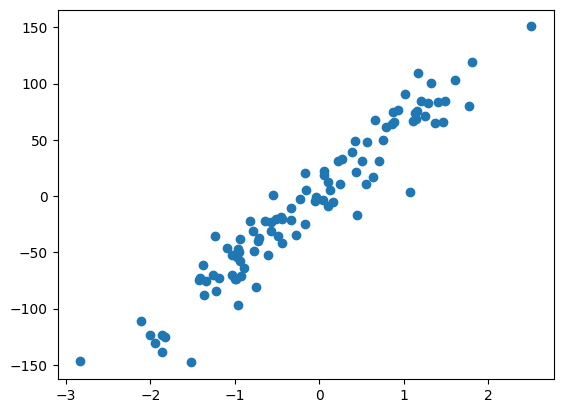

In [8]:
plt.scatter(X, y)
plt.show()

In [9]:
#train the model using the linear regression model
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()
lr.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
print(lr.coef_)
print(lr.intercept_)

[60.6892352]
1.5892065051903073


In [12]:
#using ridge regression
from sklearn.linear_model import Ridge

In [27]:
R = Ridge(alpha=10)
R.fit(X, y)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [28]:
print(R.coef_)
print(R.intercept_)

[55.7135093]
0.8943379930477873


In [29]:
R1 = Ridge(alpha=100)
R1.fit(X, y)

,alpha,100
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [30]:
print(R1.coef_)
print(R1.intercept_)

[32.05826908]
-2.40915619301217


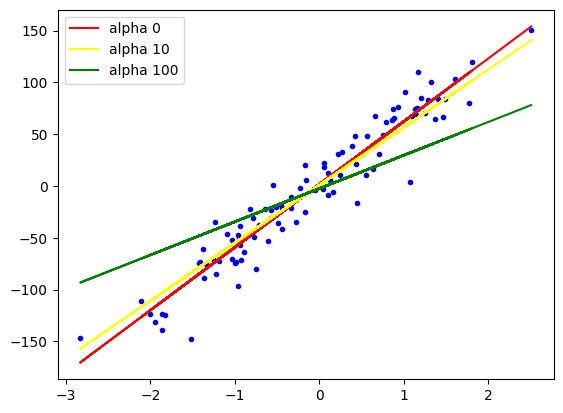

In [31]:
plt.plot(X, y, 'b.')
plt.plot(X, lr.predict(X), color = 'red', label = 'alpha 0')
plt.plot(X, R.predict(X), color = 'yellow', label = 'alpha 10')
plt.plot(X, R1.predict(X), color = 'green', label = 'alpha 100')
plt.legend()
plt.show()

In [ ]:
#ridge regression from scratch

class RidgeRegression:
    def __init__(self, alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
    def fit(self, X_train, y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + np.sum((y_train[i] - y_train.mean())*(X_train[i] - X_train.mean()))
            den = den + np.sum((X_train[i] - X_train.mean())**2)

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m * X_train.mean())

        print(self.m, self.b)
    
    def predict(self, y_test):
        y_pred = self.m * X + self.b
        return y_pred

In [50]:
rid = RidgeRegression(10)

In [51]:
rid.fit(X, y)

55.71350930178593 0.8943379930477882


In [2]:
from sklearn.datasets import load_diabetes
import numpy as np
from sklearn.metrics import r2_score

In [3]:
X, y = load_diabetes(return_X_y=True)

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [6]:
from sklearn.linear_model import Ridge

In [7]:
rr = Ridge(alpha=0.1, solver='cholesky')

In [8]:
rr.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [9]:
y_pred0 = rr.predict(X_test)

In [10]:
print(rr.coef_)
print(rr.intercept_)
print(r2_score(y_test, y_pred0))

[ -23.37285968 -214.68873597  499.95944367  252.81929892 -113.21521284
  -68.57195984 -202.06488813  142.72996785  405.82300398  131.83159687]
151.2465505143036
0.5186179131914384


In [40]:
#generalization of Ridge regression

class MeroRidge:

    def __init__(self, alpha = 0.1):
        self.alpha = alpha
        self.intercept_ = None
        self.coef_ = None
    
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)

        I = np.identity(X_train.shape[1])

        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha*I).dot(X_train.T).dot(y_train)

        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
        return result

    def predict(self, y_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred

In [41]:
mr = MeroRidge()

In [42]:
mr.fit(X_train, y_train)

array([ 151.20356194,  -23.38336665, -214.69105608,  499.96716271,
        252.82391835, -113.23247445,  -68.55176976, -202.05589088,
        142.71906224,  405.77920904,  131.84346968])

In [43]:
y_pred1 = mr.predict(X_test)

In [44]:
print(mr.intercept_)
print(mr.coef_)
print(r2_score(y_test, y_pred1))

151.2035619386808
[ -23.38336665 -214.69105608  499.96716271  252.82391835 -113.23247445
  -68.55176976 -202.05589088  142.71906224  405.77920904  131.84346968]
0.5185460405714377
